7장 시계열 예측

In [1]:
# 예제 7.1 LSTM 파라미터 수

import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import LSTM, Dense

sequence_length = 240
feature = 5

inputs = Input(shape=(sequence_length, feature))
x = LSTM(8)(inputs)
outputs = Dense(1)(x)

model = Model(inputs, outputs, name='LSTM')

model.summary()

Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 240, 5)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 8)                   │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 457 (1.79 KB)

 Trainable params: 457 (1.79 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 예제 7.2 주가 예측

# finance-datareader 설치
!pip install finance-datareader

In [3]:
# 셋업
import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.utils import timeseries_dataset_from_array
import FinanceDataReader as fdr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 데이터셋 준비
df = fdr.DataReader('005930', '2010-01-01', '2023-12-31')   # 삼성전자

In [4]:
# 상위 데이터 출력
df.head()

,Open,High,Low,Close,Volume,Change
Date,,,,,,
2010-01-04,16060,16180,16000,16180,239271,0.012516
2010-01-05,16520,16580,16300,16440,559219,0.016069
2010-01-06,16580,16820,16520,16820,459755,0.023114
2010-01-07,16820,16820,16260,16260,443237,-0.033294
2010-01-08,16400,16420,16120,16420,295798,0.009840


In [5]:
# 불필요한 컬럼 제거
df = df.drop('Change', axis=1)

In [6]:
# 정규화
min = df.min()
max = df.max()

stock_df = (df - min) / (max - min)

In [7]:
# 시퀀스 데이터셋 준비
sequence_length = 3   # 3일간의 데이터 입력
offset = 1   # 다음 날 주가 예측
shift = sequence_length + offset - 1   # 레이블 위치

train_ds = timeseries_dataset_from_array(   # 학습 데이터셋
    data=stock_df['2010-01':'2021-12'].to_numpy()[:-shift],
    targets=stock_df['Close']['2010-01':'2021-12'].to_numpy()[shift:],
    sequence_length=sequence_length,
    batch_size=32,
    shuffle=False)

valid_ds = timeseries_dataset_from_array(   # 검증 데이터셋
    data=stock_df['2022-01':'2022-12'].to_numpy()[:-shift],
    targets=stock_df['Close']['2022-01':'2022-12'].to_numpy()[shift:],
    sequence_length=sequence_length,
    batch_size=32,
    shuffle=False)

test_ds = timeseries_dataset_from_array(   # 테스트 데이터셋
    data=stock_df['2023-01':'2023-12'].to_numpy()[:-shift],
    targets=stock_df['Close']['2023-01':'2023-12'].to_numpy()[shift:],
    sequence_length=sequence_length,
    batch_size=32,
    shuffle=False)

In [8]:
# 모델 생성
inputs = Input(shape=(sequence_length, 5))   # 입력 특징 5개
x = LSTM(8, return_sequences=True)(inputs)
x = LSTM(8)(x)
outputs = Dense(1)(x)

model = Model(inputs, outputs)

In [9]:
# 모델 컴파일
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

In [10]:
# 모델 학습
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',   # 모니터링 지표 지정
    patience=3)           # 허용 범위 지정

history = model.fit(train_ds, epochs=50, verbose=0,
                    validation_data=valid_ds,
                    callbacks=early_stopping)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step


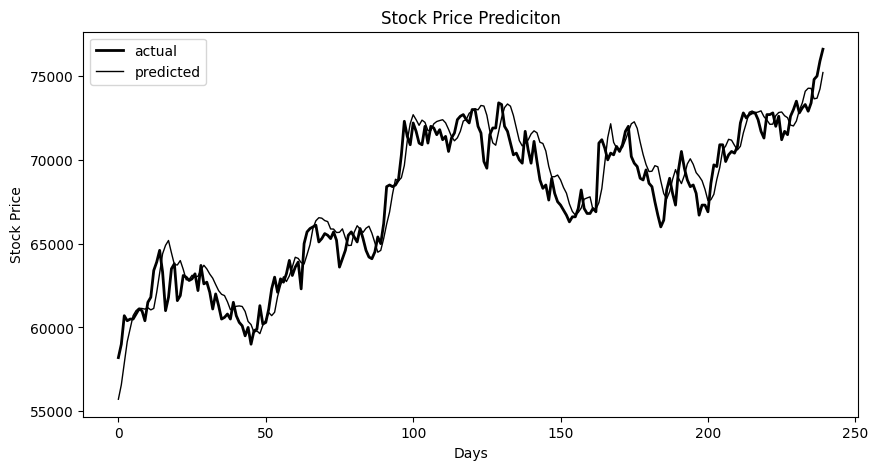

In [11]:
# 예측 결과 시각화
max_C = df['Close'].max()   # 종가의 최대값
min_C = df['Close'].min()   # 종가의 최소값

y_pred = model.predict(test_ds)
y_pred = y_pred * (max_C - min_C) + min_C

y_test = []
for _, targets in test_ds:
    y_test.extend(targets)
y_test = np.array(y_test) * (max_C - min_C) + min_C

plt.figure(figsize=(10, 5))

plt.plot(y_test, label='actual', color='black', linewidth=2)
plt.plot(y_pred, label='predicted', color='black', linewidth=1)
plt.xlabel('Days')
plt.ylabel('Stock Price')
plt.title('Stock Price Prediciton')
plt.legend()

plt.show()